In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime, timezone
from scipy.signal import detrend, butter, filtfilt
from scipy.integrate import cumulative_trapezoid
 
import seisbench.models as sbm
from obspy import Stream, Trace, UTCDateTime

In [2]:
H5_PATH    = r'/root/autodl-tmp/Test_on_Event/chichi/Chichi/Chichi.h5'
EVENT_NAME = 'chichi'
HALF_DEG   = 0.75       # 台站筛选半径 = 模型网格半径
V_P_KM_S   = 6.0
V_S_KM_S   = 3.5

PHASENET_PROB_THRESHOLD = 0.3
USE_S_PICK = False
 
T_P_TOLERANCE_S = 3.0
T_S_TOLERANCE_S = 8.0
 
# STA/LTA fallback（在速度上做）
STA_S = 0.5; LTA_S = 5.0; STA_LTA_THRESH = 3.0
 
# acc→vel 预处理参数
HP_HZ = 0.10; LP_HZ = 10.0; FILT_ORD = 4
 
T_WINDOW     = (-5, 80)
DISPLAY_BAND = (0.5, 10.0)
 
CACHE_PATH = Path(H5_PATH).parent / f'{EVENT_NAME}_picks.csv'

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin(np.radians(lat2 - lat1) / 2)**2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(np.radians(lon2 - lon1) / 2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))
 
def parse_time(s):
    s = str(s).strip().replace('Z', '+00:00')
    try:   dt = datetime.fromisoformat(s)
    except ValueError: dt = datetime.strptime(s, '%Y-%m-%dT%H:%M:%S')
    return dt.replace(tzinfo=timezone.utc) if dt.tzinfo is None else dt
 
def acc_to_vel(acc, sr, hp=HP_HZ, lp=LP_HZ, order=FILT_ORD):
    """加速度(cm/s²) → 速度(cm/s)"""
    x = np.asarray(acc, dtype=np.float64)
    n_pre = max(1, min(20, len(x) // 10))
    x -= np.median(x[:n_pre])
    x = detrend(x, type='linear')
    nyq = sr / 2.0
    b, a = butter(order, [max(hp/nyq, 1e-5), min(lp/nyq, 0.999)], btype='band')
    x = filtfilt(b, a, x)
    v = cumulative_trapezoid(x, dx=1.0/sr, initial=0.0)
    v = detrend(v, type='linear')
    b2, a2 = butter(2, max(0.05/nyq, 1e-5), btype='high')
    return filtfilt(b2, a2, v).astype(np.float32)
 
def bandpass_vel(vel, sr, fmin=0.5, fmax=10.0, order=4):
    nyq = sr / 2.0
    b, a = butter(order, [max(fmin/nyq, 1e-5), min(fmax/nyq, 0.999)], btype='band')
    return filtfilt(b, a, vel).astype(np.float32)
 
def sta_lta_trigger(arr, sr, sta_s=0.5, lta_s=5.0, threshold=3.0):
    data = np.abs(np.asarray(arr, dtype=np.float64))
    n = len(data); n_sta = max(1, int(round(sta_s*sr))); n_lta = max(1, int(round(lta_s*sr)))
    if n < n_lta + n_sta: return np.inf
    cs = np.concatenate([[0.0], np.cumsum(data)])
    ratio = np.zeros(n)
    for i in range(n_lta, n):
        sta = (cs[i+1] - cs[max(0, i+1-n_sta)]) / n_sta
        lta = (cs[i+1] - cs[i+1-n_lta]) / n_lta
        ratio[i] = sta / (lta + 1e-12) if lta > 1e-12 else 0.0
    trig = np.where(ratio[n_lta:] >= threshold)[0]
    return float((n_lta + trig[0]) / sr) if len(trig) else np.inf
 
def make_stream(acc_ew, acc_ns, acc_v, sr, t0_utc, sid):
    """EW→HHE, NS→HHN, V→HHZ（输入原始加速度）"""
    arrs = [acc_ew, acc_ns, acc_v]
    min_len = min(len(a) for a in arrs if a is not None and len(a) > 0)
    if min_len == 0: return None
    st = Stream()
    for arr, cha in zip(arrs, ['HHE', 'HHN', 'HHZ']):
        if arr is None: arr = np.zeros(min_len, dtype=np.float32)
        tr = Trace(); tr.data = np.asarray(arr[:min_len], dtype=np.float64)
        tr.stats.sampling_rate = sr; tr.stats.starttime = t0_utc
        tr.stats.network = 'TW'; tr.stats.station = sid[:5]; tr.stats.channel = cha
        st.append(tr)
    return st
 
def phasenet_pick(stream, model, prob_threshold, use_s):
    try: anno = model.annotate(stream)
    except Exception: return np.inf
    for target in (['S','P'] if use_s else ['P','S']):
        traces = [tr for tr in anno if target in tr.stats.channel]
        if not traces: continue
        tr = traces[0]; prob = tr.data.astype(np.float32)
        p_sr = tr.stats.sampling_rate
        p_t0 = tr.stats.starttime.timestamp - stream[0].stats.starttime.timestamp
        above = np.where(prob >= prob_threshold)[0]
        if len(above): return float(p_t0 + above[0] / p_sr)
    return np.inf

In [4]:
with h5py.File(H5_PATH, 'r') as f:
    eq = f['earthquake']
    EQ_LAT = float(eq.attrs['latitude']); EQ_LON = float(eq.attrs['longitude'])
    EQ_DEP = float(eq.attrs['depth']);    EQ_MAG = float(eq.attrs['magnitude'])
    ORI_TIME = parse_time(eq.attrs['origin_time'])
print(f'M{EQ_MAG}  {EQ_LAT:.4f}N  {EQ_LON:.4f}E  depth={EQ_DEP:.1f} km  {ORI_TIME.isoformat()}')
 
# %%
print('Loading PhaseNet ...')
phasenet = sbm.PhaseNet.from_pretrained('stead'); phasenet.eval()
print('PhaseNet ready.')

M7.6  23.8620N  120.8140E  depth=11.0 km  1999-09-20T17:47:00+00:00
Loading PhaseNet ...
PhaseNet ready.


In [5]:
records = []
with h5py.File(H5_PATH, 'r') as f:
    for sid, grp in f['stations'].items():
        sta_lat = float(grp.attrs.get('latitude', 0.0))
        sta_lon = float(grp.attrs.get('longitude', 0.0))
        if abs(sta_lat-EQ_LAT) > HALF_DEG or abs(sta_lon-EQ_LON) > HALF_DEG: continue
        if 'waveforms' not in grp: continue
 
        def _load(key):
            if key in grp['waveforms']:
                a = np.asarray(grp['waveforms'][key][:], dtype=np.float32).reshape(-1)
                return a if a.size > 0 else None
            return None
 
        acc_ew = _load('EW'); acc_ns = _load('NS'); acc_v = _load('V')
        if acc_ew is None and acc_ns is None: continue
 
        sr         = float(grp.attrs.get('sampling_rate', 250.0))
        rec_start  = parse_time(grp.attrs['record_time'])
        # CHN-TW: rec_offset = -PreEventTime（固定负值，e.g. -11s）
        rec_offset = (rec_start - ORI_TIME).total_seconds()
 
        dist_km    = haversine_km(EQ_LAT, EQ_LON, sta_lat, sta_lon)
        dist_3d    = np.sqrt(dist_km**2 + EQ_DEP**2)
        t_p_theory = dist_3d / V_P_KM_S
        t_s_theory = dist_3d / V_S_KM_S
        t_theory   = t_p_theory if not USE_S_PICK else t_s_theory
        tolerance  = T_P_TOLERANCE_S if not USE_S_PICK else T_S_TOLERANCE_S
 
        # acc → vel
        vel_ew = acc_to_vel(acc_ew, sr) if acc_ew is not None else None
        vel_ns = acc_to_vel(acc_ns, sr) if acc_ns is not None else None
        vel_v  = acc_to_vel(acc_v,  sr) if acc_v  is not None else None
 
        # ① PhaseNet（输入加速度）
        source   = 'phasenet'
        t0_utc   = UTCDateTime(rec_start.timestamp())
        stream   = make_stream(acc_ew, acc_ns, acc_v, sr, t0_utc, sid)
        t_in_rec = phasenet_pick(stream, phasenet, PHASENET_PROB_THRESHOLD, USE_S_PICK) \
                   if stream else np.inf
        t_pick   = t_in_rec + rec_offset if np.isfinite(t_in_rec) else np.inf
 
        # ② STA/LTA fallback（速度上）
        if not np.isfinite(t_pick) or abs(t_pick - t_theory) > tolerance:
            vel_ref  = vel_ew if vel_ew is not None else vel_ns
            t_stalta = sta_lta_trigger(vel_ref, sr, STA_S, LTA_S, STA_LTA_THRESH) \
                       if vel_ref is not None else np.inf
            t_stalta_abs = t_stalta + rec_offset if np.isfinite(t_stalta) else np.inf
            if np.isfinite(t_stalta_abs) and abs(t_stalta_abs - t_theory) <= tolerance:
                t_pick = t_stalta_abs; source = 'sta_lta_fallback'
            else:
                t_pick = t_theory; source = 'theoretical'  # ③
 
        # 显示用速度
        vel_disp = vel_ew if vel_ew is not None else vel_ns
        if vel_disp is not None and DISPLAY_BAND:
            try: vel_disp = bandpass_vel(vel_disp, sr, *DISPLAY_BAND)
            except Exception: pass
        if vel_disp is None or len(vel_disp) == 0: continue
 
        t_a = np.arange(len(vel_disp), dtype=np.float32) / sr + rec_offset
        msk = (t_a >= T_WINDOW[0]) & (t_a <= T_WINDOW[1])
        if msk.sum() < 10: continue
 
        records.append({
            'sid': sid, 'sta_lat': sta_lat, 'sta_lon': sta_lon,
            'dist_km': dist_km, 'dist_3d_km': dist_3d,
            'sr': sr, 'rec_offset': rec_offset,
            't_p_theory': t_p_theory, 't_s_theory': t_s_theory,
            'trigger_abs_s': float(t_pick), 'source': source,
            't': t_a[msk], 'vel': vel_disp[msk],
            'pgv': float(np.max(np.abs(vel_disp[msk]))),
        })
 
records.sort(key=lambda r: r['dist_km'])
n_pn = sum(1 for r in records if r['source']=='phasenet')
n_sl = sum(1 for r in records if r['source']=='sta_lta_fallback')
n_th = sum(1 for r in records if r['source']=='theoretical')
print(f'台站(筛选后): {len(records)}  PhaseNet:{n_pn}  STA/LTA:{n_sl}  理论:{n_th}')

台站(筛选后): 69  PhaseNet:6  STA/LTA:35  理论:28


In [6]:
rows = [{'station_id': r['sid'], 'p_pick_s': r['trigger_abs_s'],
         'dist_km': r['dist_km'], 'dist_3d_km': r['dist_3d_km'],
         'theoretical_p_s': r['t_p_theory'], 'theoretical_s_s': r['t_s_theory'],
         'source': r['source'], 'pgv_cms': r['pgv']} for r in records]
df_out = pd.DataFrame(rows)
df_out.to_csv(CACHE_PATH, index=False)
print(f'Picks saved → {CACHE_PATH}')

Picks saved → /root/autodl-tmp/Test_on_Event/chichi/Chichi/chichi_picks.csv


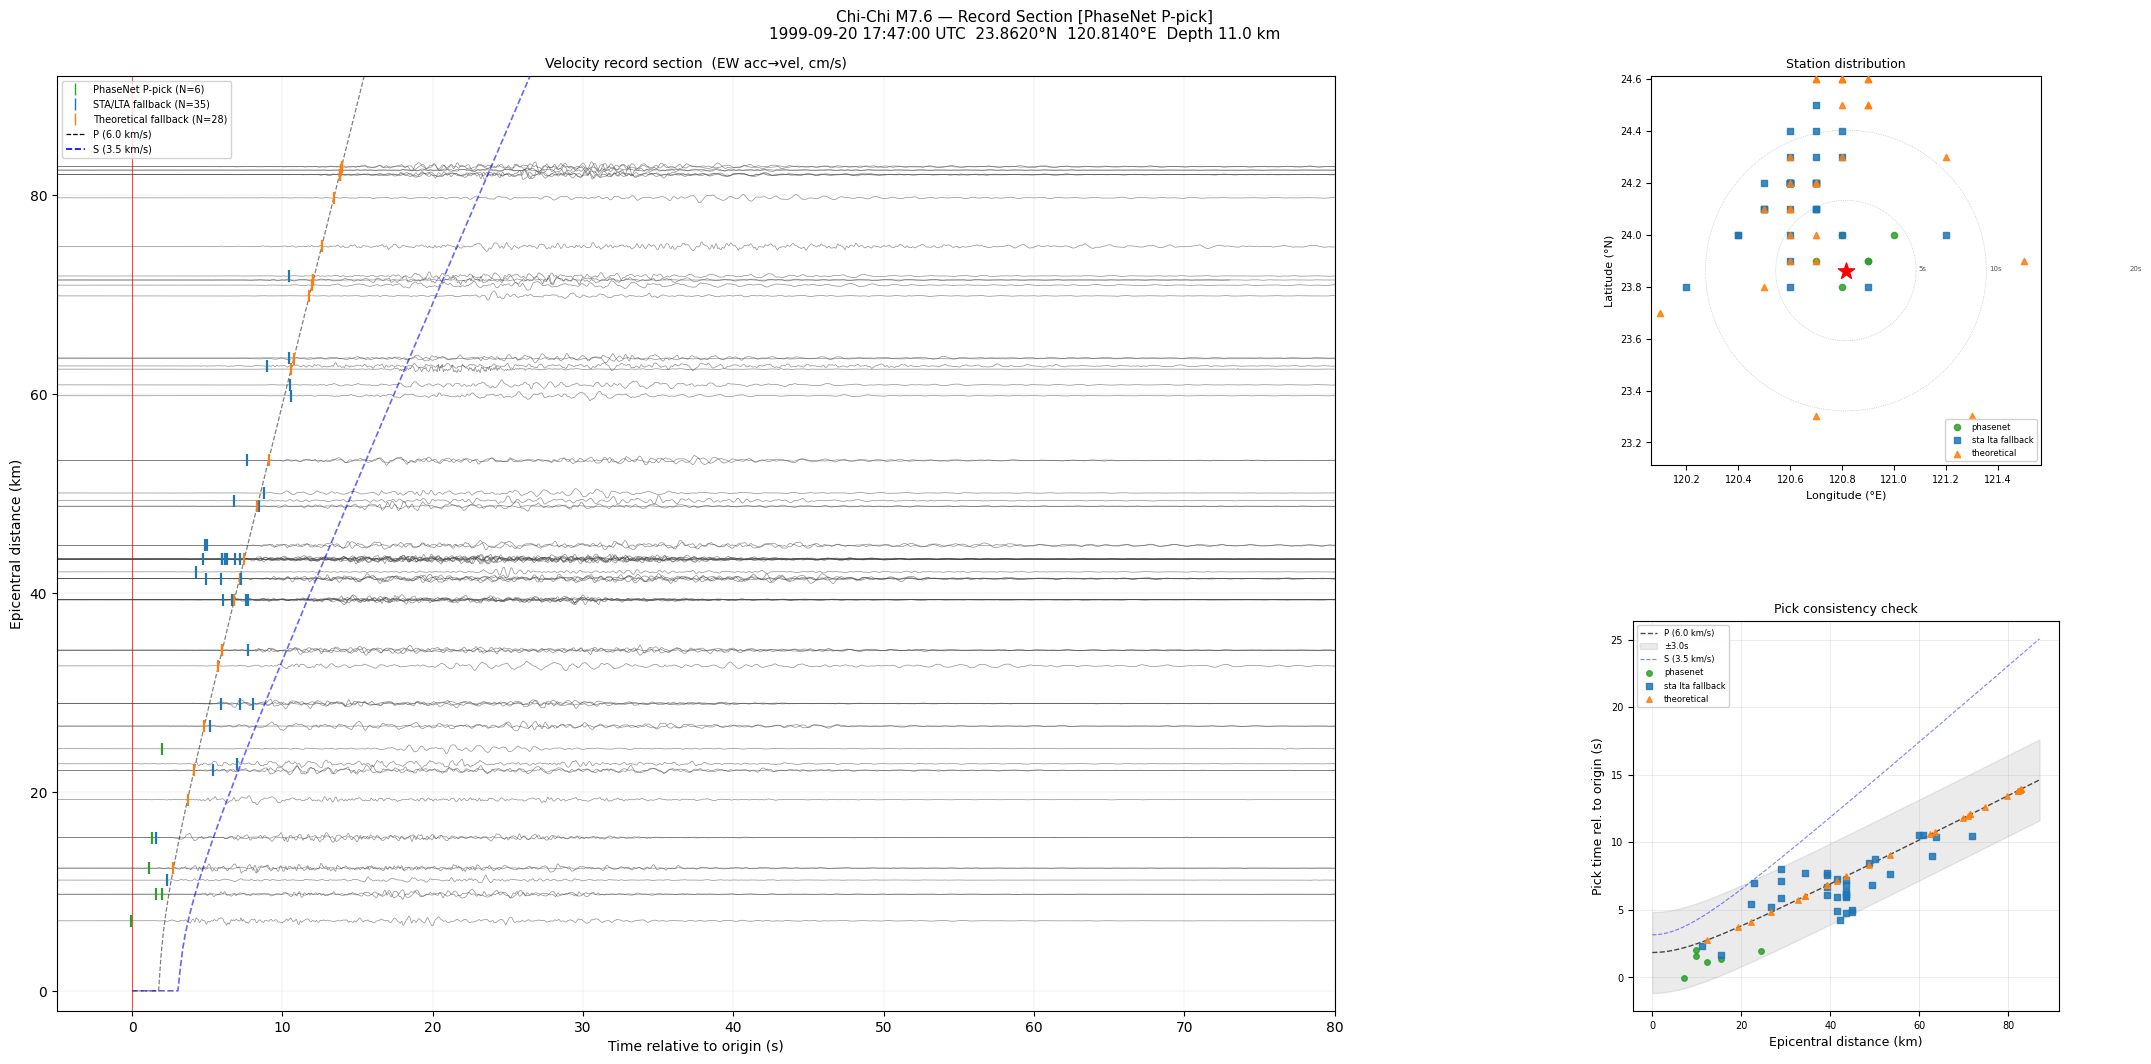

Figure saved → /root/autodl-tmp/Test_on_Event/chichi/Chichi/chichi_record_section.png


In [7]:
COLOR  = {'phasenet':'#2ca02c','sta_lta_fallback':'#1f77b4','theoretical':'#ff7f0e'}
MARKER = {'phasenet':'o','sta_lta_fallback':'s','theoretical':'^'}
LABEL  = {'phasenet':f'PhaseNet P-pick (N={n_pn})',
          'sta_lta_fallback':f'STA/LTA fallback (N={n_sl})',
          'theoretical':f'Theoretical fallback (N={n_th})'}
 
dist_max = max((r['dist_km'] for r in records), default=200.0) * 1.05
fig = plt.figure(figsize=(22,11))
fig.suptitle(f'Chi-Chi M{EQ_MAG} — Record Section [PhaseNet P-pick]\n'
             f'{ORI_TIME.strftime("%Y-%m-%d %H:%M:%S UTC")}  '
             f'{EQ_LAT:.4f}°N  {EQ_LON:.4f}°E  Depth {EQ_DEP:.1f} km',
             fontsize=11, y=0.98)
gs = gridspec.GridSpec(2,2,width_ratios=[3,1],hspace=0.4,wspace=0.35,
                       left=0.06,right=0.97,top=0.92,bottom=0.07)
ax_rec  = fig.add_subplot(gs[:,0])
ax_map  = fig.add_subplot(gs[0,1])
ax_pick = fig.add_subplot(gs[1,1])
 
SCALE=0.5; MIN_NORM=1e-3; seen=set()
for r in records:
    amp = float(np.max(np.abs(r['vel']))+MIN_NORM)
    ax_rec.plot(r['t'], r['vel']/amp*SCALE+r['dist_km'],
                lw=0.5, color='#444', alpha=0.6, rasterized=True)
    ax_rec.plot(r['trigger_abs_s'], r['dist_km'], marker='|',
                ms=8, mew=1.6, color=COLOR[r['source']], zorder=4)
    seen.add(r['source'])
 
t_arr = np.linspace(0, T_WINDOW[1], 500)
ax_rec.plot(t_arr, np.sqrt(np.maximum((V_P_KM_S*t_arr)**2-EQ_DEP**2,0)), 'k--', lw=0.9, alpha=0.5)
ax_rec.plot(t_arr, np.sqrt(np.maximum((V_S_KM_S*t_arr)**2-EQ_DEP**2,0)), 'b--', lw=1.2, alpha=0.6)
ax_rec.axvline(0, color='red', lw=0.8, alpha=0.7)
handles = [*[Line2D([0],[0],marker='|',color=COLOR[s],ms=8,lw=0,label=LABEL[s])
             for s in ('phasenet','sta_lta_fallback','theoretical') if s in seen],
           Line2D([0],[0],ls='--',color='k',lw=0.9,label=f'P ({V_P_KM_S} km/s)'),
           Line2D([0],[0],ls='--',color='b',lw=1.2,label=f'S ({V_S_KM_S} km/s)')]
ax_rec.legend(handles=handles, fontsize=7, loc='upper left', framealpha=0.85)
ax_rec.set_xlim(T_WINDOW); ax_rec.set_ylim(-2, dist_max+5)
ax_rec.set_xlabel('Time relative to origin (s)', fontsize=10)
ax_rec.set_ylabel('Epicentral distance (km)', fontsize=10)
ax_rec.set_title('Velocity record section  (EW acc→vel, cm/s)', fontsize=10)
ax_rec.grid(lw=0.3, alpha=0.4)
 
lon_min,lon_max = EQ_LON-HALF_DEG, EQ_LON+HALF_DEG
lat_min,lat_max = EQ_LAT-HALF_DEG, EQ_LAT+HALF_DEG
for src in ('phasenet','sta_lta_fallback','theoretical'):
    grp_r = [r for r in records if r['source']==src]
    if grp_r:
        ax_map.scatter([r['sta_lon'] for r in grp_r],[r['sta_lat'] for r in grp_r],
                       s=20, c=COLOR[src], marker=MARKER[src], zorder=3, alpha=0.85,
                       label=src.replace('_',' '))
ax_map.scatter([EQ_LON],[EQ_LAT], s=150, c='red', marker='*', zorder=5)
for t_s in [5,10,20]:
    r_deg = V_P_KM_S*t_s/111.0; theta = np.linspace(0,2*np.pi,300)
    ax_map.plot(EQ_LON+r_deg*np.cos(theta), EQ_LAT+r_deg*np.sin(theta),
                color='#888', lw=0.5, ls=':', alpha=0.6)
    ax_map.text(EQ_LON+r_deg+0.01, EQ_LAT, f'{t_s}s', fontsize=5, color='#555')
ax_map.set_xlim(lon_min,lon_max); ax_map.set_ylim(lat_min,lat_max)
ax_map.set_aspect('equal')
ax_map.set_xlabel('Longitude (°E)',fontsize=8); ax_map.set_ylabel('Latitude (°N)',fontsize=8)
ax_map.set_title('Station distribution',fontsize=9)
ax_map.legend(fontsize=6,loc='lower right',framealpha=0.9); ax_map.tick_params(labelsize=7)
 
d_r = np.linspace(0,dist_max,300)
t_p_th = np.sqrt(d_r**2+EQ_DEP**2)/V_P_KM_S
t_s_th = np.sqrt(d_r**2+EQ_DEP**2)/V_S_KM_S
ax_pick.plot(d_r,t_p_th,'k--',lw=1.0,alpha=0.7,label=f'P ({V_P_KM_S} km/s)')
ax_pick.fill_between(d_r,t_p_th-T_P_TOLERANCE_S,t_p_th+T_P_TOLERANCE_S,
                     color='black',alpha=0.08,label=f'±{T_P_TOLERANCE_S}s')
ax_pick.plot(d_r,t_s_th,'b--',lw=0.8,alpha=0.5,label=f'S ({V_S_KM_S} km/s)')
for src in ('phasenet','sta_lta_fallback','theoretical'):
    grp_r = [r for r in records if r['source']==src]
    if grp_r:
        ax_pick.scatter([r['dist_km'] for r in grp_r],
                        [r['trigger_abs_s'] for r in grp_r],
                        s=16, c=COLOR[src], marker=MARKER[src], alpha=0.85, zorder=3,
                        label=src.replace('_',' '))
ax_pick.set_xlabel('Epicentral distance (km)',fontsize=9)
ax_pick.set_ylabel('Pick time rel. to origin (s)',fontsize=9)
ax_pick.set_title('Pick consistency check',fontsize=9)
ax_pick.legend(fontsize=6,loc='upper left',framealpha=0.9)
ax_pick.grid(lw=0.4,alpha=0.4); ax_pick.tick_params(labelsize=7)
 
out_png = Path(H5_PATH).parent / f'{EVENT_NAME}_record_section.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.show()
print(f'Figure saved → {out_png}')

In [8]:
print('\n─── Pick summary ─────────────────────────────────────────────────')
print(df_out[['station_id','dist_km','p_pick_s','theoretical_p_s',
              'source','pgv_cms']].to_string(index=False))


─── Pick summary ─────────────────────────────────────────────────
   station_id   dist_km  p_pick_s  theoretical_p_s           source    pgv_cms
       TCU078  7.039617 -0.060000         2.176619         phasenet  32.405048
       TCU084  9.711487  1.580000         2.445591         phasenet 107.343079
       TCU089  9.711487  2.000000         2.445591         phasenet  24.593210
       TCU079 11.137610  2.330000         2.608993 sta_lta_fallback  67.823296
       TCU076 12.337141  2.754819         2.754819      theoretical  18.888536
       TCU129 12.337141  1.150000         2.754819         phasenet  64.628731
       TCL071 15.410730  1.615000         3.155641 sta_lta_fallback  37.886581
       TCU072 15.410730  1.320000         3.155641         phasenet  48.561321
       TCU075 19.227921  3.692007         3.692007      theoretical  24.057377
       TCU116 22.165000  4.124073         4.124073      theoretical  22.194296
       TCU138 22.165000  5.388000         4.124073 sta_lta_fall